DataFrame dtypes after scaling and one-hot encoding:
Trip_ID                                           object
Trip_Start_Time                           datetime64[ns]
Stamp                                     datetime64[ns]
Destination                                       object
Distance_km                                      float64
Boarding                                           int64
Alighting                                          int64
month                                            float64
day                                              float64
hour                                             float64
minute                                           float64
time_of_day                                      float64
net                                                int64
passenger_load                                     int64
prev_load                                        float64
holiday_type_Deepavali Festival Day                 bool
holiday_type_Esala Full Moon Poya D

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 128)         │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,835 (565.76 KB)

 Trainable params: 144,835 (565.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
420/421 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 77.9852
Epoch 1: val_loss improved from inf to 37.32998, saving model to best_passenger_flow_lstm.keras
421/421 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - loss: 77.9080 - val_loss: 37.3300 - learning_rate: 0.0010
Epoch 2/500
419/421 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 35.1468
Epoch 2: val_loss improved from 37.32998 to 25.26029, saving model to best_passenger_flow_lstm.keras
421/421 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 35.1249 - val_loss: 25.2603 - learning_rate: 0.0010
Epoch 3/500
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 26.5456
Epoch 3: val_loss improved from 25.26029 to 21.82435, saving model to best_passenger_flow_lstm.keras
421/421 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 26.5432 - val_loss: 21.8244 - learning_rate: 0.0010
Epoch 4/500
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 23.6784
Epoch 4: val_loss improved from 21.82435 to 21.17406, saving model to best_passenger_flow_lstm.keras
421/421 ━━━━

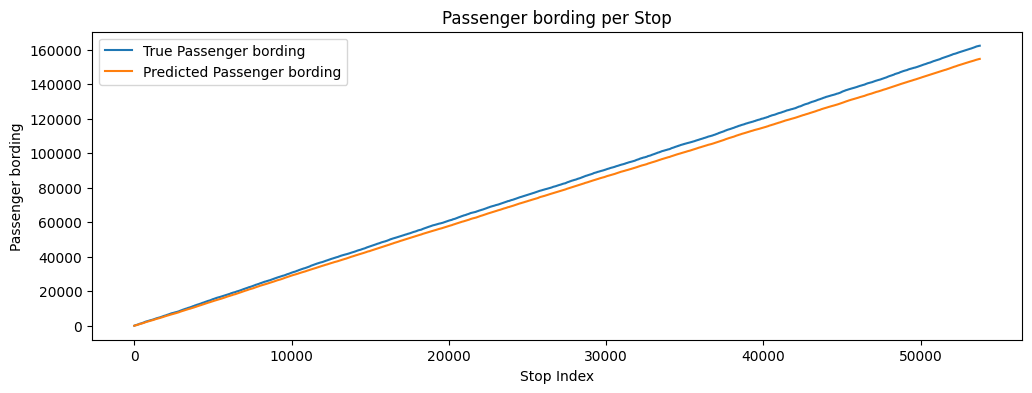

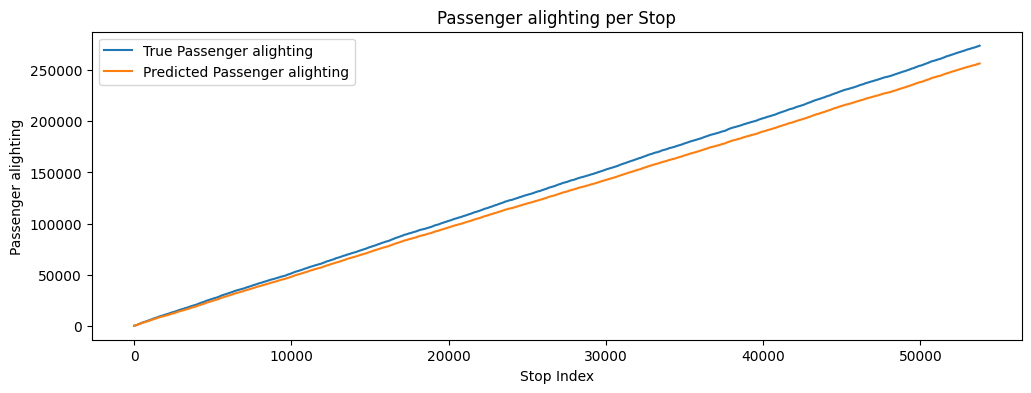

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# -----------------------------
# CONFIG
# -----------------------------
CSV_FILE = "final_dataset copy.csv"
SEQ_LEN = 5
EPOCHS = 500
BATCH_SIZE = 512
VAL_SIZE = 0.2
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv(CSV_FILE, parse_dates=["Stamp", "Trip_Start_Time"])

df["Boarding"] = pd.to_numeric(df["Boarding"], errors="coerce").fillna(0)
df["Alighting"] = pd.to_numeric(df["Alighting"], errors="coerce").fillna(0)
df["Distance_km"] = pd.to_numeric(df["Distance_km"], errors="coerce").fillna(0)

# -----------------------------
# 2. DATE & TIME FEATURES
# -----------------------------
df["month"] = df["Stamp"].dt.month
df["day"] = df["Stamp"].dt.day
df["hour"] = df["Stamp"].dt.hour
df["minute"] = df["Stamp"].dt.minute
df["time_of_day"] = df["hour"] + df["minute"]/60  # scaled later

# -----------------------------
# 3. PASSENGER LOAD & NET
# -----------------------------
df = df.sort_values(["Trip_ID", "Stamp"])
df["net"] = df["Boarding"] - df["Alighting"]
df["passenger_load"] = df.groupby("Trip_ID")["net"].cumsum()
df["passenger_load"] = df["passenger_load"].clip(lower=0)

# previous load
df['prev_load'] = df.groupby('Trip_ID')['passenger_load'].shift(1).fillna(0)

# -----------------------------
# 4. ONE-HOT ENCODE CATEGORICALS
# -----------------------------
cat_cols = ["holiday_type", "day_type", "trip_direction", "Origin", "Route"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# -----------------------------
# 5. SCALE NUMERIC FEATURES
# -----------------------------
numeric_cols = ["month", "day", "Distance_km", "hour", "minute", "time_of_day", "prev_load"]
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
joblib.dump(scaler, "numeric_scaler.save")

# Diagnostic: Print dtypes after all preprocessing to identify any remaining non-numeric columns
print("DataFrame dtypes after scaling and one-hot encoding:")
print(df.dtypes)

# -----------------------------
# 6. FEATURE / TARGET COLUMNS
# -----------------------------
target_cols = ["Boarding", "Alighting", "net"]  # predict net change
drop_cols = ["Stamp", "Trip_Start_Time", "Destination", "Trip_ID", "passenger_load", "record_type"] + target_cols
feature_cols = [c for c in df.columns if c not in drop_cols]
joblib.dump(feature_cols, "passenger_flow_features.save") # Save feature columns

for i, c in enumerate(feature_cols):
    print(f"{i:02d} -> {c}")

print("Number of feature columns:", len(feature_cols))

# -----------------------------
# 7. BUILD SEQUENCES
# -----------------------------
X, Y = [], []

for trip_id, g in df.groupby("Trip_ID"):
    g = g.sort_values("Stamp")
    fvals = g[feature_cols].values.astype("float32")
    tvals = g[target_cols].values.astype("float32")

    if len(g) <= SEQ_LEN:
        continue

    for i in range(len(g) - SEQ_LEN):
        X.append(fvals[i:i + SEQ_LEN])
        Y.append(tvals[i + SEQ_LEN])

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# -----------------------------
# 8. TRAIN / VALIDATION SPLIT
# -----------------------------
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=VAL_SIZE, random_state=SEED, shuffle=True
)

# -----------------------------
# 9. LSTM MODEL
# -----------------------------
# Corrected model definition with explicit Input layer
model = Sequential([
    Input(shape=(SEQ_LEN, len(feature_cols))), # Explicitly define input shape
    LSTM(128, return_sequences=True),
    Dropout(0.4),
    LSTM(64, return_sequences=True),
    Dropout(0.4),
    LSTM(32),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(3)  # Boarding, Alighting, Net
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()

# -----------------------------
# 10. CALLBACKS
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_passenger_flow_lstm.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# -----------------------------
# 11. TRAIN
# -----------------------------
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, model_checkpoint], # Added model_checkpoint
    verbose=1
)

model.save("passenger_flow_lstm.keras")
print("Model saved")

# -----------------------------
# 12. EVALUATE
# -----------------------------
Y_pred = model.predict(X_val)
boarding_mae = np.mean(np.abs(Y_pred[:,0] - Y_val[:,0]))
boarding_rmse = np.sqrt(np.mean((Y_pred[:,0] - Y_val[:,0])**2))
boarding_r2 = r2_score(Y_val[:,0], Y_pred[:,0]) # Calculate R^2 for net change
alighting_mae = np.mean(np.abs(Y_pred[:,1] - Y_val[:,1]))
alighting_rmse = np.sqrt(np.mean((Y_pred[:,1] - Y_val[:,1])**2))
alighting_r2 = r2_score(Y_val[:,1], Y_pred[:,1]) # Calculate R^2 for net change
net_mae = np.mean(np.abs(Y_pred[:,2] - Y_val[:,2]))
net_rmse = np.sqrt(np.mean((Y_pred[:,2] - Y_val[:,2])**2))
net_r2 = r2_score(Y_val[:,2], Y_pred[:,2]) # Calculate R^2 for net change

print(f"Boarding - MAE: {boarding_mae:.2f}, RMSE: {boarding_rmse:.2f},R^2: {boarding_r2:.2f}")
print(f"Alighting - MAE: {alighting_mae:.2f}, RMSE: {alighting_rmse:.2f},R^2: {alighting_r2:.2f}")
print(f"Net Change - MAE: {net_mae:.2f}, RMSE: {net_rmse:.2f}, R^2: {net_r2:.2f}")

# Store for global summary
global_pf_boarding_mae = boarding_mae
global_pf_boarding_rmse = boarding_rmse
global_pf_alighting_mae = alighting_mae
global_pf_alighting_rmse = alighting_rmse
global_pf_net_mae = net_mae
global_pf_net_rmse = net_rmse
global_pf_net_r2 = net_r2

# -----------------------------
# 13. VISUALIZATION
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(Y_val[:,0].cumsum(), label="True Passenger bording")
plt.plot(np.cumsum(Y_pred[:,0]), label="Predicted Passenger bording")
plt.xlabel("Stop Index")
plt.ylabel("Passenger bording")
plt.title("Passenger bording per Stop")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(Y_val[:,1].cumsum(), label="True Passenger alighting")
plt.plot(np.cumsum(Y_pred[:,1]), label="Predicted Passenger alighting")
plt.xlabel("Stop Index")
plt.ylabel("Passenger alighting")
plt.title("Passenger alighting per Stop")
plt.legend()
plt.show()


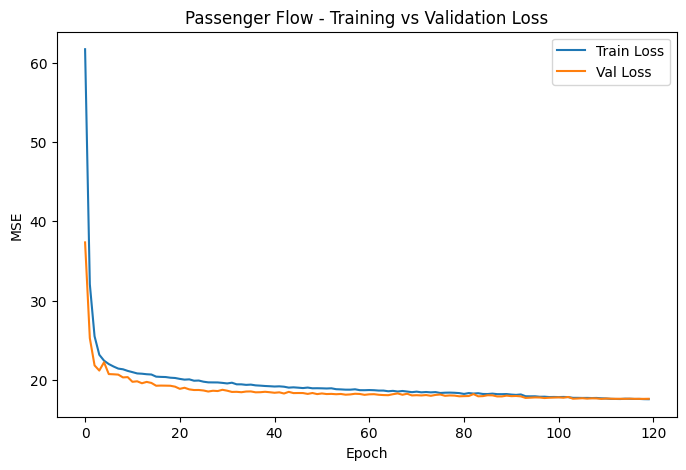

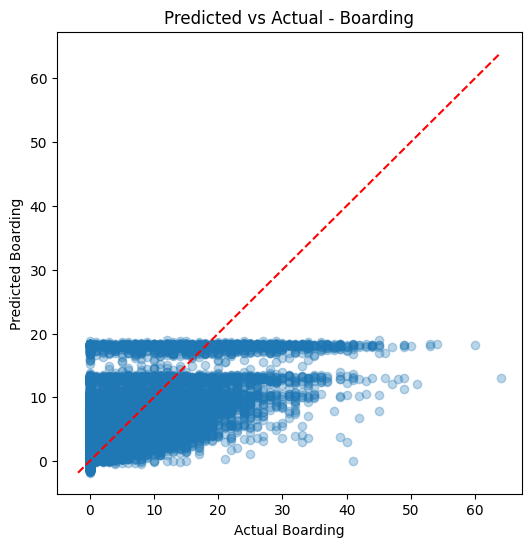

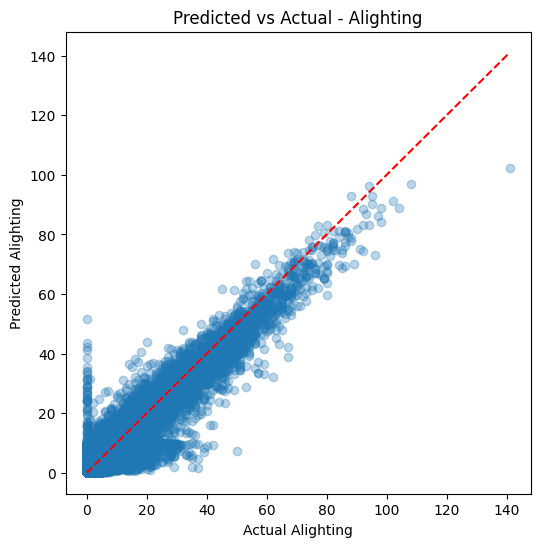

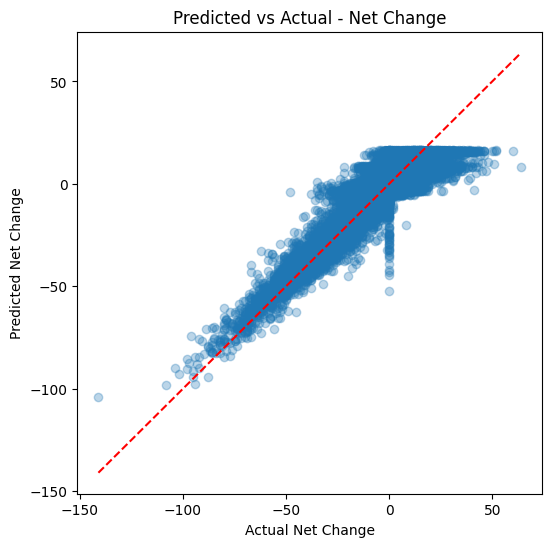

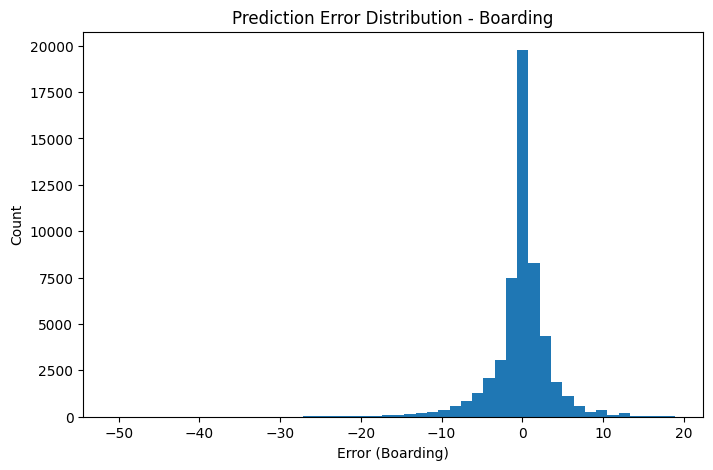

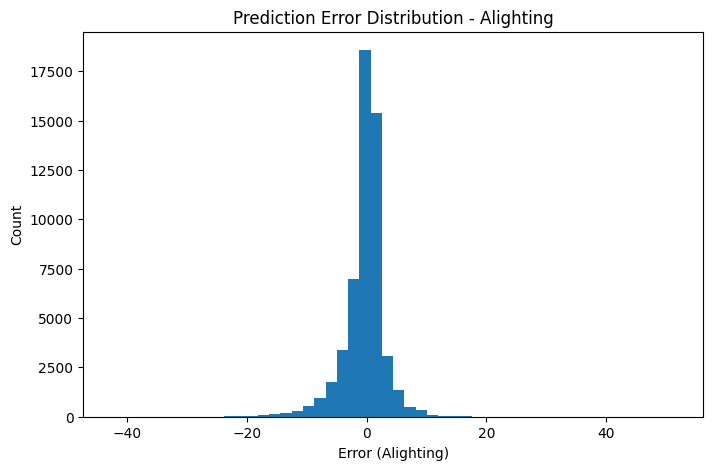

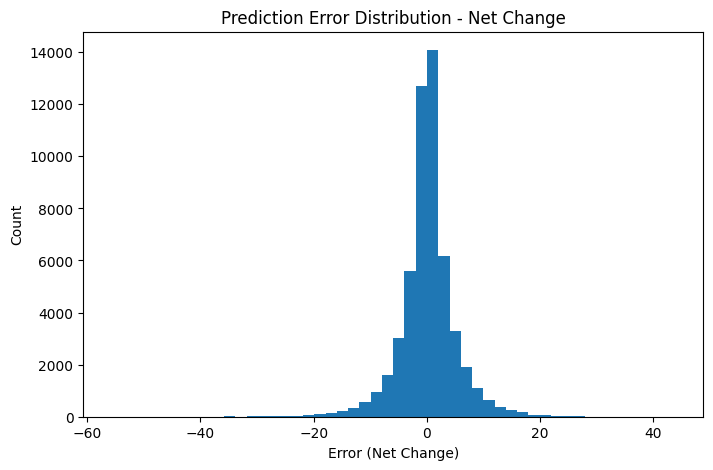

In [2]:
# Passenger Flow: Training vs Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Passenger Flow - Training vs Validation Loss")
plt.show()

# Predicted vs Actual scatter plots for Boarding, Alighting, Net Change
targets = [("Boarding", 0), ("Alighting", 1), ("Net Change", 2)]
for name, idx in targets:
    y_true = Y_val[:, idx]
    y_pred = Y_pred[:, idx]

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "r--")
    plt.xlabel(f"Actual {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f"Predicted vs Actual - {name}")
    plt.show()

# Error distributions for each target
for name, idx in targets:
    errors = (Y_pred[:, idx] - Y_val[:, idx])

    plt.figure(figsize=(8,5))
    plt.hist(errors, bins=50)
    plt.xlabel(f"Error ({name})")
    plt.ylabel("Count")
    plt.title(f"Prediction Error Distribution - {name}")
    plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import joblib

# Load trained passenger flow model and preprocessing artifacts
model = tf.keras.models.load_model("best_passenger_flow_lstm.keras")
scaler = joblib.load("numeric_scaler.save")
feature_cols = joblib.load("passenger_flow_features.save")

SEQ_LEN = 3
NUM_FEATURES = len(feature_cols)

def build_frame(month, day, dist_km, hour, minute, prev_load,
                holiday_type, day_type, trip_direction,
                origin, route):
    vec = np.zeros(NUM_FEATURES, dtype="float32")

    # Scale numeric inputs
    time_of_day = hour + minute / 60
    scaled = scaler.transform([[
        month,
        day,
        dist_km,
        hour,
        minute,
        time_of_day,
        prev_load
    ]])[0]

    numeric_map = {
        "Distance_km": scaled[2],
        "month": scaled[0],
        "day": scaled[1],
        "hour": scaled[3],
        "minute": scaled[4],
        "time_of_day": scaled[5],
        "prev_load": scaled[6],
    }
    for name, value in numeric_map.items():
        if name in feature_cols:
            vec[feature_cols.index(name)] = value

    # One-hot for categoricals using feature column names
    def set_one(name):
        if name in feature_cols:
            vec[feature_cols.index(name)] = 1.0

    set_one(f"holiday_type_{holiday_type}")
    set_one(f"day_type_{day_type}")
    set_one(f"trip_direction_{trip_direction}")
    set_one(f"Origin_{origin}")
    set_one(f"Route_{route}")

    return vec

# Example sequence of 3 frames
sequence = [
    {
        "month": 8, "day": 14, "dist_km": 1.5, "hour": 14, "minute": 30, "prev_load": 84,
        "holiday_type": "none", "day_type": "weekend", "trip_direction": "1",
        "origin": "Kaduwela", "route": "177 - Kollupitiya - Kaduwela"
    },
    {
        "month": 8, "day": 14, "dist_km": 1.6, "hour": 14, "minute": 32, "prev_load": 86,
        "holiday_type": "none", "day_type": "weekend", "trip_direction": "1",
        "origin": "Kothalawala", "route": "177 - Kollupitiya - Kaduwela"
    },
    {
        "month": 8, "day": 14, "dist_km": 1.7, "hour": 14, "minute": 35, "prev_load": 85,
        "holiday_type": "none", "day_type": "weekend", "trip_direction": "1",
        "origin": "Pittugala", "route": "177 - Kollupitiya - Kaduwela"
    },
]

# Build model input tensor
X_input = np.zeros((1, SEQ_LEN, NUM_FEATURES), dtype="float32")
for t, s in enumerate(sequence):
    X_input[0, t, :] = build_frame(
        s["month"], s["day"], s["dist_km"], s["hour"], s["minute"], s["prev_load"],
        s["holiday_type"], s["day_type"], s["trip_direction"],
        s["origin"], s["route"]
    )

# Predict boarding, alighting, and net change for the next stop
pred = model.predict(X_input)
print("Boarding:", round(float(pred[0][0]), 2))
print("Alighting:", round(float(pred[0][1]), 2))
print("Net change:", round(float(pred[0][2]), 2))


c:\Users\Samarakoon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Samarakoon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Samarakoon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
Boarding: 1.44
Alighting: 28.55
Net change: -26.98


Arrival Time

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 4, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 8)      │         88 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 8)      │         88 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4, 19)     │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0],  │
│                     │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 4, 19)     │         38 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     21,504 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,831 (93.09 KB)

 Trainable params: 23,831 (93.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8853 - mae: 0.7066
Epoch 1: val_loss improved from inf to 0.81386, saving model to best_arrival_time_lstm.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.8851 - mae: 0.7065 - val_loss: 0.8139 - val_mae: 0.6761 - learning_rate: 0.0010
Epoch 2/500
225/228 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8284 - mae: 0.6793
Epoch 2: val_loss improved from 0.81386 to 0.80161, saving model to best_arrival_time_lstm.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.8283 - mae: 0.6792 - val_loss: 0.8016 - val_mae: 0.6604 - learning_rate: 0.0010
Epoch 3/500
226/228 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8142 - mae: 0.6698
Epoch 3: val_loss improved from 0.80161 to 0.79554, saving model to best_arrival_time_lstm.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.8142 - mae: 0.6698 - val_loss: 0.7955 - val_mae: 0.6660 - learning_rate: 0.0010
Epoch 4/500
226/228 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8130

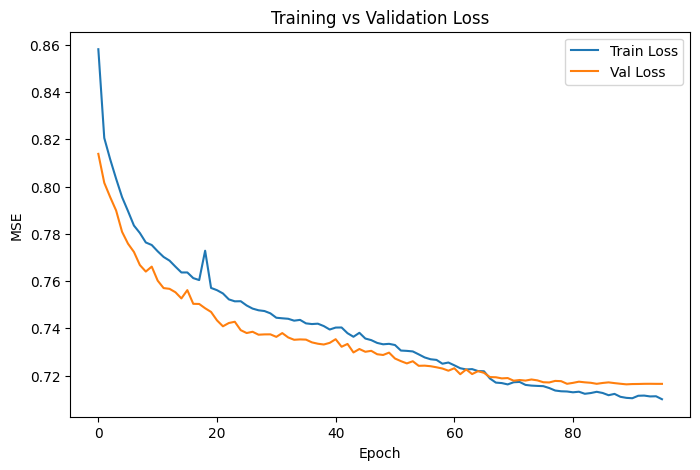

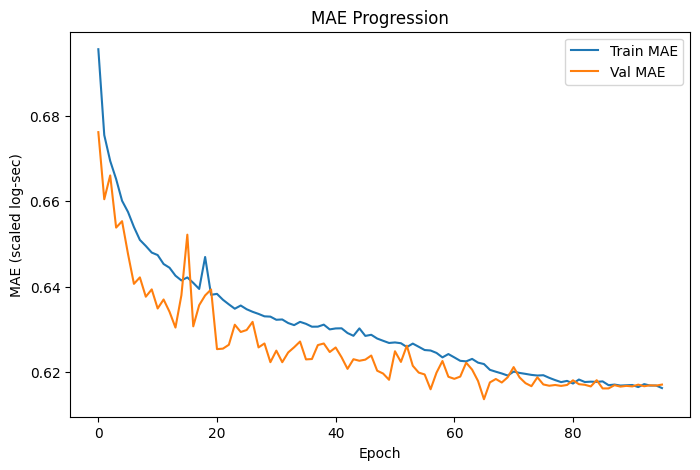

906/906 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


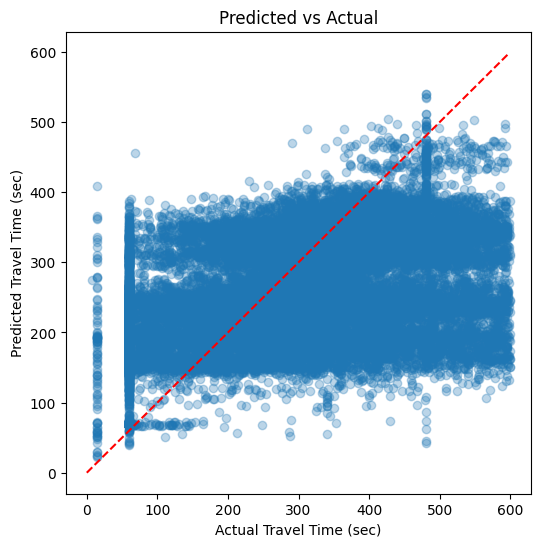

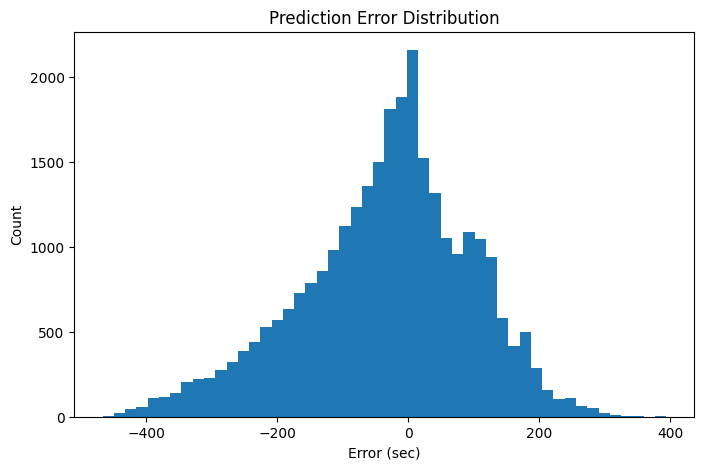

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout,
    Embedding, Concatenate, LayerNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


CSV_FILE = "final_dataset copy.csv"
SEQ_LEN = 4
EPOCHS = 500
BATCH_SIZE = 512
VAL_SIZE = 0.2
SEED = 42

df = pd.read_csv(CSV_FILE)

df["Stamp"] = pd.to_datetime(df["Stamp"])
df = df.sort_values(["Trip_ID", "Stamp"])

df["travel_time_sec"] = (
    df.groupby("Trip_ID")["Stamp"].shift(-1) - df["Stamp"]
).dt.total_seconds()

df = df.dropna(subset=["travel_time_sec"])


# Remove GPS spikes & unrealistic delays
df = df[(df["travel_time_sec"] > 5) & (df["travel_time_sec"] < 600)]

stop_encoder = LabelEncoder()

df["origin_id"] = stop_encoder.fit_transform(df["Origin"])
df["dest_id"]   = stop_encoder.transform(df["Destination"])
joblib.dump(stop_encoder, "arrival_time_stop_encoder.save")


df["hour"]   = df["Stamp"].dt.hour
df["minute"] = df["Stamp"].dt.minute


num_features = ["Distance_km", "hour", "minute"]

x_scaler = StandardScaler()
df[num_features] = x_scaler.fit_transform(df[num_features])
joblib.dump(x_scaler, "arrival_time_x_scaler.save")


df["travel_time_sec"] = np.log1p(df["travel_time_sec"])

y_scaler = StandardScaler()
df["travel_time_sec"] = y_scaler.fit_transform(
    df[["travel_time_sec"]]
)
joblib.dump(y_scaler, "arrival_time_y_scaler.save")




def build_sequences(df):
    X_num, X_origin, X_dest, y = [], [], [], []

    for _, trip in df.groupby("Trip_ID"):
        if len(trip) <= SEQ_LEN:
            continue

        for i in range(len(trip) - SEQ_LEN):
            X_num.append(trip[num_features].iloc[i:i+SEQ_LEN].values)
            X_origin.append(trip["origin_id"].iloc[i:i+SEQ_LEN].values)
            X_dest.append(trip["dest_id"].iloc[i:i+SEQ_LEN].values)
            y.append(trip["travel_time_sec"].iloc[i+SEQ_LEN])

    return (
        np.array(X_num),
        np.array(X_origin),
        np.array(X_dest),
        np.array(y)
    )


trip_ids = df["Trip_ID"].unique()

train_ids, val_ids = train_test_split(
    trip_ids, test_size=0.2, random_state=42
)

train_df = df[df["Trip_ID"].isin(train_ids)]
val_df   = df[df["Trip_ID"].isin(val_ids)]

Xn_tr, Xo_tr, Xd_tr, y_tr = build_sequences(train_df)
Xn_va, Xo_va, Xd_va, y_va = build_sequences(val_df)


num_input    = Input(shape=(SEQ_LEN, len(num_features)))
origin_input = Input(shape=(SEQ_LEN,))
dest_input   = Input(shape=(SEQ_LEN,))

origin_emb = Embedding(len(stop_encoder.classes_), 8)(origin_input)
dest_emb   = Embedding(len(stop_encoder.classes_), 8)(dest_input)

x = Concatenate()([num_input, origin_emb, dest_emb])
x = LayerNormalization()(x)

x = LSTM(
    64,
    kernel_regularizer=l2(1e-5),
    return_sequences=False
)(x)

x = Dropout(0.4)(x)
x = Dense(32, activation="relu")(x)
output = Dense(1)(x)

model = Model(
    inputs=[num_input, origin_input, dest_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_arrival_time_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)


history = model.fit(
    [Xn_tr, Xo_tr, Xd_tr],
    y_tr,
    validation_data=([Xn_va, Xo_va, Xd_va], y_va),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

model.save("arrival_time_lstm.keras")

print("Model saved")

# Predict on validation set
y_pred_val = model.predict([Xn_va, Xo_va, Xd_va]).flatten()

# Inverse scale and inverse log-transform
y_pred_unscaled = y_scaler.inverse_transform(y_pred_val.reshape(-1, 1)).ravel()
y_true_unscaled = y_scaler.inverse_transform(y_va.reshape(-1, 1)).ravel()
y_pred_sec = np.expm1(y_pred_unscaled)
y_true_sec = np.expm1(y_true_unscaled)

# Metrics in seconds
val_mae = mean_absolute_error(y_true_sec, y_pred_sec)
val_rmse = np.sqrt(mean_squared_error(y_true_sec, y_pred_sec))
val_r2 = r2_score(y_true_sec, y_pred_sec)

print(f"ArrivelTime prediction Validation - MAE: {val_mae:.2f} sec, RMSE: {val_rmse:.2f} sec, R^2: {val_r2:.3f}")

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (scaled log-sec)")
plt.legend()
plt.title("MAE Progression")
plt.show()


y_pred = model.predict([Xn_va, Xo_va, Xd_va])

y_pred = y_scaler.inverse_transform(y_pred)
y_true = y_scaler.inverse_transform(y_va.reshape(-1,1))

y_pred = np.expm1(y_pred)
y_true = np.expm1(y_true)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.plot([0, y_true.max()], [0, y_true.max()], "r--")
plt.xlabel("Actual Travel Time (sec)")
plt.ylabel("Predicted Travel Time (sec)")
plt.title("Predicted vs Actual")
plt.show()


errors = (y_pred - y_true).flatten()

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.xlabel("Error (sec)")
plt.ylabel("Count")
plt.title("Prediction Error Distribution")
plt.show()


In [2]:
import numpy as np
import tensorflow as tf
import joblib

model = tf.keras.models.load_model("best_arrival_time_lstm.keras")

def predict_arrival_time(
    model,
    origin,
    destination,
    distance,
    hour,
    minute,
    last_seq=None
):
    origin_id = stop_encoder.transform([origin])[0]
    dest_id   = stop_encoder.transform([destination])[0]

    num = x_scaler.transform([[distance, hour, minute]])

    if last_seq is None:
        num_seq = np.repeat(num[np.newaxis, :, :], SEQ_LEN, axis=1)
        origin_seq = np.full((1, SEQ_LEN), origin_id)
        dest_seq   = np.full((1, SEQ_LEN), dest_id)
    else:
        num_seq, origin_seq, dest_seq = last_seq

    pred = model.predict([num_seq, origin_seq, dest_seq])
    pred = y_scaler.inverse_transform(pred)
    pred = np.expm1(pred)

    return float(pred[0][0])


t = predict_arrival_time(
    model,
    origin="Kothalawala",
    destination="Pittugala",
    distance=1.8,
    hour=15,
    minute=35
)

print(f"Predicted arrival time: {t/60:.2f} minutes")


c:\Users\Samarakoon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Predicted arrival time: 4.56 minutes
